# **Filtrado Basado en Contenido v2**

En este notebook, implementamos una versión mejorada del filtrado basado en contenido que incorpora tanto características numéricas como textuales (TF-IDF) para generar recomendaciones más precisas.

### **Importación de componentes**

In [1]:
import sys
import os

project_root = os.path.abspath('..')
if project_root not in sys.path:
    sys.path.append(project_root)

try:
    from pipeline.vectorizers import vectorize_text_tfidf, vectorize_numerical
    from models.enhanced_content_based import generate_user_vector, recommend_by_content, recommend_hybrid_content
    from evaluation.metrics import precision_at_k, recall_at_k, ndcg_at_k
except ImportError as e:
    print(f"Error de importación: {e}")

## **1. Carga de datos**

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Configuramos el estilo de los gráficos
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('viridis')
plt.rcParams['figure.figsize'] = [10, 6]

# Cargamos los datos preprocesados generados en el cuaderno de preparación de datos
df = pd.read_csv("../data/preprocessed_data.csv")

# Mostramos las primeras filas del DataFrame
df.head()

,Unnamed: 0,breed,description,temperament,popularity,min_height,max_height,min_weight,max_weight,min_expectancy,...,shedding_category,energy_level_value,energy_level_category,trainability_value,trainability_category,demeanor_value,demeanor_category,description_length,temperament_length,text_combined
0,0,affenpinscher,affen apish look described many way called mon...,confident famously funny fearless,148,22.86,29.21,3.175147,4.535924,12.0,...,seasonal,0.6,regular_exercise,0.8,easy_training,1.0,outgoing,159,4,affen apish look described many way called mon...
1,1,afghan_hound,afghan hound ancient breed whole appearance on...,dignified profoundly loyal aristocratic,113,63.50,68.58,22.679619,27.215542,12.0,...,infrequent,0.8,energetic,0.2,may_be_stubborn,0.2,aloof/wary,235,4,afghan hound ancient breed whole appearance on...
2,2,airedale_terrier,airedale terrier largest terrier breed male st...,friendly clever courageous,60,58.42,58.42,22.679619,31.751466,11.0,...,occasional,0.6,regular_exercise,1.0,eager_to_please,0.8,friendly,156,3,airedale terrier largest terrier breed male st...
3,3,akita,akitas burly heavy boned spitz type dog imposi...,courageous dignified profoundly loyal,47,60.96,71.12,31.751466,58.967008,10.0,...,seasonal,0.8,energetic,1.0,eager_to_please,0.6,alert/responsive,152,4,akitas burly heavy boned spitz type dog imposi...
4,4,alaskan_malamute,alaskan malamute stand inch shoulder weighs po...,affectionate loyal playful,58,58.42,63.50,34.019428,38.555351,10.0,...,seasonal,0.8,energetic,0.4,independent,0.8,friendly,161,3,alaskan malamute stand inch shoulder weighs po...


## **2. Vectorización de características**

In [3]:
from pipeline.vectorizers import vectorize_text_tfidf, vectorize_numerical

# Vectorizar características de texto
X_text, tfidf_model = vectorize_text_tfidf(df)

# Vectorizar características numéricas
numerical_columns = [
    "grooming_frequency_value",
    "shedding_value",
    "energy_level_value",
    "trainability_value",
    "demeanor_value"
]

X_num, scaler = vectorize_numerical(df, numerical_columns)

# Mostrar dimensiones de vectores
print(f"Dimensiones de vectores de texto: {X_text.shape}")
print(f"Dimensiones de vectores numéricos: {X_num.shape}")

Dimensiones de vectores de texto: (277, 500)
Dimensiones de vectores numéricos: (277, 5)


## **3. Desarrollo del modelo**

En la versión anterior del modelo, se identificó que unicamente empleaba información relacionada a las características numéricas para el entrenamiento y generación de las recomendaciones, a pesar de que se generaba el modelo de características textuales, este nunca se usaba. En esta mejora, incorporamos tanto las características numéricas como las textuales (TF-IDF). El desarrollo se realizó considerando los siguientes puntos:

1. Permitir definir consultas de texto para modelar preferencias textuales
2. Integrar un peso relativo entre características numéricas y textuales para comparación

In [10]:
# Creamos perfiles de usuario para pruebas
test_profiles = [
    {
        "nombre": "Usuario con familia",
        "grooming_frequency_value": 0.4,  # Poco mantenimiento
        "shedding_value": 0.4,            # Poca caída de pelo
        "energy_level_value": 0.6,        # Energía media
        "trainability_value": 0.8,        # Buena capacidad de entrenamiento
        "demeanor_value": 1.0,            # Muy amigable
        "text_query": "friendly family children"  # Consulta de texto
    },
    {
        "nombre": "Usuario deportista",
        "grooming_frequency_value": 0.6,  # Mantenimiento medio
        "shedding_value": 0.6,            # Caída de pelo media
        "energy_level_value": 1.0,        # Muy energético
        "trainability_value": 1.0,        # Muy entrenable
        "demeanor_value": 0.6,            # Temperamento medio
        "text_query": "energetic active outdoor"  # Consulta de texto
    },
    {
        "nombre": "Usuario en apartamento",
        "grooming_frequency_value": 0.8,  # Alto mantenimiento
        "shedding_value": 0.2,            # Mínima caída de pelo
        "energy_level_value": 0.4,        # Poca energía
        "trainability_value": 0.6,        # Entrenabilidad media
        "demeanor_value": 0.8,            # Bastante amigable
        "text_query": "low energy calm"   # Consulta de texto
    },
    {
        "nombre": "Usuario mayor",
        "grooming_frequency_value": 0.6,  # Mantenimiento medio
        "shedding_value": 0.2,            # Mínima caída de pelo
        "energy_level_value": 0.2,        # Muy poca energía
        "trainability_value": 0.6,        # Entrenabilidad media
        "demeanor_value": 1.0,            # Muy amigable
        "text_query": "calm gentle companion senior low energy"  # Consulta de texto
    },
    {
        "nombre": "Usuario primerizo",
        "grooming_frequency_value": 0.4,  # Poco mantenimiento
        "shedding_value": 0.4,            # Poca caída de pelo
        "energy_level_value": 0.4,        # Poca energía
        "trainability_value": 1.0,        # Muy entrenable
        "demeanor_value": 0.8,            # Bastante amigable
        "text_query": "easy to train beginner friendly low maintenance"  # Consulta de texto
    },
    {
        "nombre": "Usuario con niños pequeños",
        "grooming_frequency_value": 0.6,  # Mantenimiento medio
        "shedding_value": 0.4,            # Poca caída de pelo
        "energy_level_value": 0.6,        # Energía media
        "trainability_value": 0.8,        # Buena capacidad de entrenamiento
        "demeanor_value": 1.0,            # Muy amigable
        "text_query": "patient gentle tolerant with children family"  # Consulta de texto
    },
    {
        "nombre": "Usuario con alergias",
        "grooming_frequency_value": 1.0,  # Muy alto mantenimiento (pelo regular)
        "shedding_value": 0.2,            # Mínima caída de pelo
        "energy_level_value": 0.6,        # Energía media
        "trainability_value": 0.6,        # Entrenabilidad media
        "demeanor_value": 0.8,            # Bastante amigable
        "text_query": "hypoallergenic non shedding low dander"  # Consulta de texto
    },
    {
        "nombre": "Usuario con fines de protección",
        "grooming_frequency_value": 0.4,  # Poco mantenimiento
        "shedding_value": 0.6,            # Caída de pelo media
        "energy_level_value": 0.8,        # Bastante energético
        "trainability_value": 0.8,        # Buena capacidad de entrenamiento
        "demeanor_value": 0.2,            # Reservado/alerta - BAJO para perros guardianes
        "text_query": "protective guard watchful alert territorial"  # Consulta de texto
    }
]

# Creamos una lista de orden de características para los perfiles de usuario
feature_order = [col for col in list(test_profiles[0].keys())[1:] if col != "text_query"]

# Comparamos recomendaciones con diferentes combinaciones de peso (alpha)
alpha_values = [1.0, 0.7, 0.5, 0.3, 0.0]
all_recommendations = {alpha: {} for alpha in alpha_values}

# Para cada perfil y cada valor de alpha, generamos recomendaciones
for profile in test_profiles:
    # Extraemos nombre, consulta de texto y preferencias numéricas
    nombre = profile["nombre"]
    text_query = profile["text_query"]
    numeric_preferences = {k: profile[k] for k in feature_order}
    
    for alpha in alpha_values:
        # Generamos el vector numérico del usuario
        user_vec = generate_user_vector(numeric_preferences, scaler, feature_order)
        
        # Hacemos recomendaciones con diferentes pesos (alpha)
        recs = recommend_by_content(
            user_vec, 
            X_num, 
            df, 
            top_k=10,
            text_query=text_query,
            text_vectors=X_text,
            tfidf_vectorizer=tfidf_model,
            alpha=alpha
        )
        
        # Guardamos las recomendaciones
        all_recommendations[alpha][nombre] = recs

# Mostramos las recomendaciones para el primer perfil con diferentes valores de alpha
primer_perfil = test_profiles[4]["nombre"]
print(f"\nComparación de recomendaciones para {primer_perfil}:")

for alpha in alpha_values:
    weight_text = f"(Num: {alpha:.1f}, Texto: {1-alpha:.1f})"
    print(f"\nCon alpha = {alpha} {weight_text}:")
    display(all_recommendations[alpha][primer_perfil][['breed', 'cbf_score', 'group']].head(5))


Comparación de recomendaciones para Usuario primerizo:

Con alpha = 1.0 (Num: 1.0, Texto: 0.0):


,breed,cbf_score,group
70,cavalier_king_charles_spaniel,1.000000,toy_group
101,english_springer_spaniel,0.909563,sporting_group
143,japanese_spitz,0.907443,foundation_stock_service
47,border_terrier,0.907443,terrier_group
162,manchester_terrier_standard,0.846397,terrier_group



Con alpha = 0.7 (Num: 0.7, Texto: 0.3):


,breed,cbf_score,group
70,cavalier_king_charles_spaniel,0.706551,toy_group
47,border_terrier,0.670979,terrier_group
101,english_springer_spaniel,0.645175,sporting_group
143,japanese_spitz,0.640589,foundation_stock_service
163,manchester_terrier_toy,0.592478,toy_group



Con alpha = 0.5 (Num: 0.5, Texto: 0.5):


,breed,cbf_score,group
47,border_terrier,0.513337,terrier_group
70,cavalier_king_charles_spaniel,0.510918,toy_group
101,english_springer_spaniel,0.468917,sporting_group
143,japanese_spitz,0.462687,foundation_stock_service
183,papillon,0.444166,toy_group



Con alpha = 0.3 (Num: 0.3, Texto: 0.7):


,breed,cbf_score,group
47,border_terrier,0.355695,terrier_group
45,bolognese,0.325442,foundation_stock_service
183,papillon,0.323849,toy_group
70,cavalier_king_charles_spaniel,0.315285,toy_group
101,english_springer_spaniel,0.292659,sporting_group



Con alpha = 0.0 (Num: 0.0, Texto: 1.0):


,breed,cbf_score,group
203,portuguese_water_dog,0.250813,working_group
236,slovakian_wirehaired_pointer,0.215641,foundation_stock_service
127,hamiltonstovare,0.207680,foundation_stock_service
53,bracco_italiano,0.207026,miscellaneous_class
111,french_spaniel,0.191555,foundation_stock_service


## **4. Análisis comparativo**

Posteriormente, se realizó una comparación para ver como se alteran las recomendaciones al variar el peso entre características numéricas y textuales.

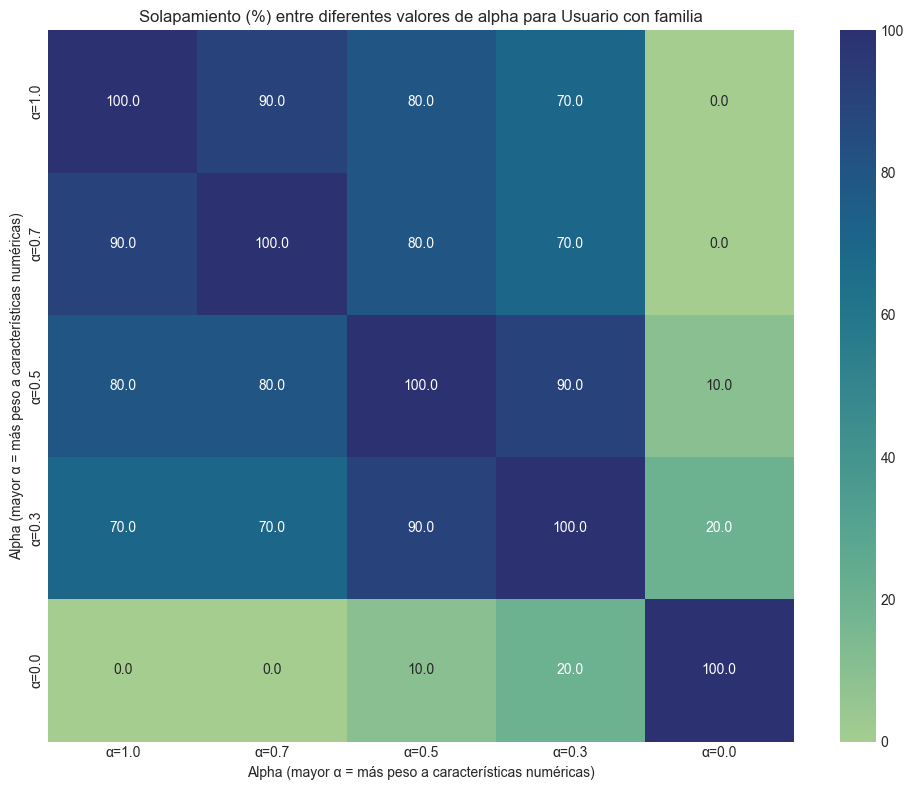

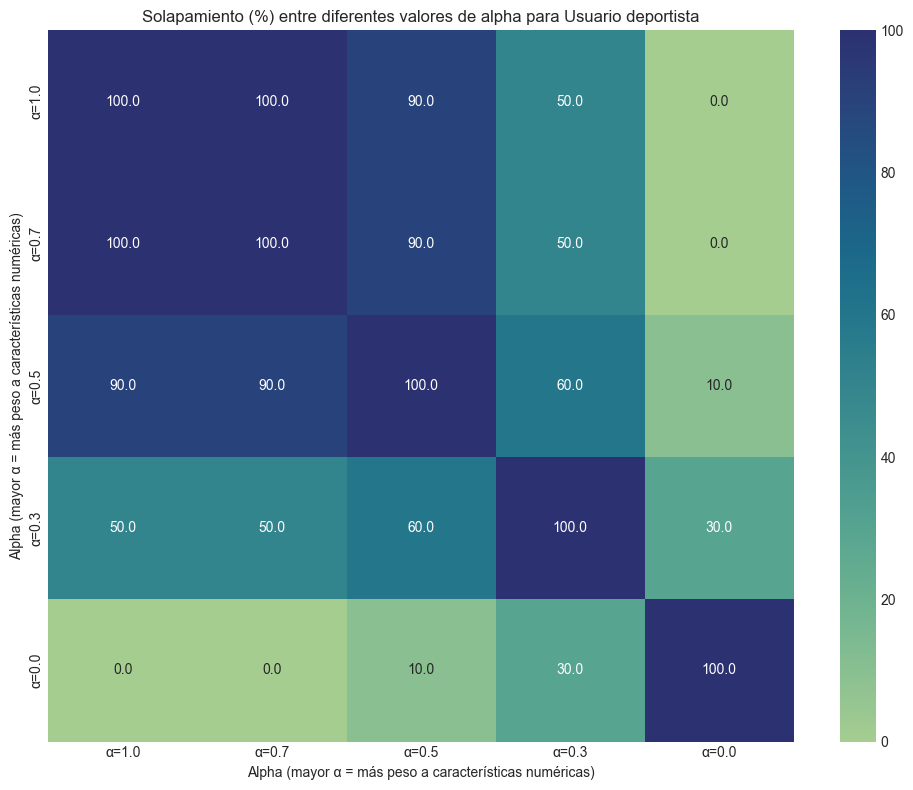

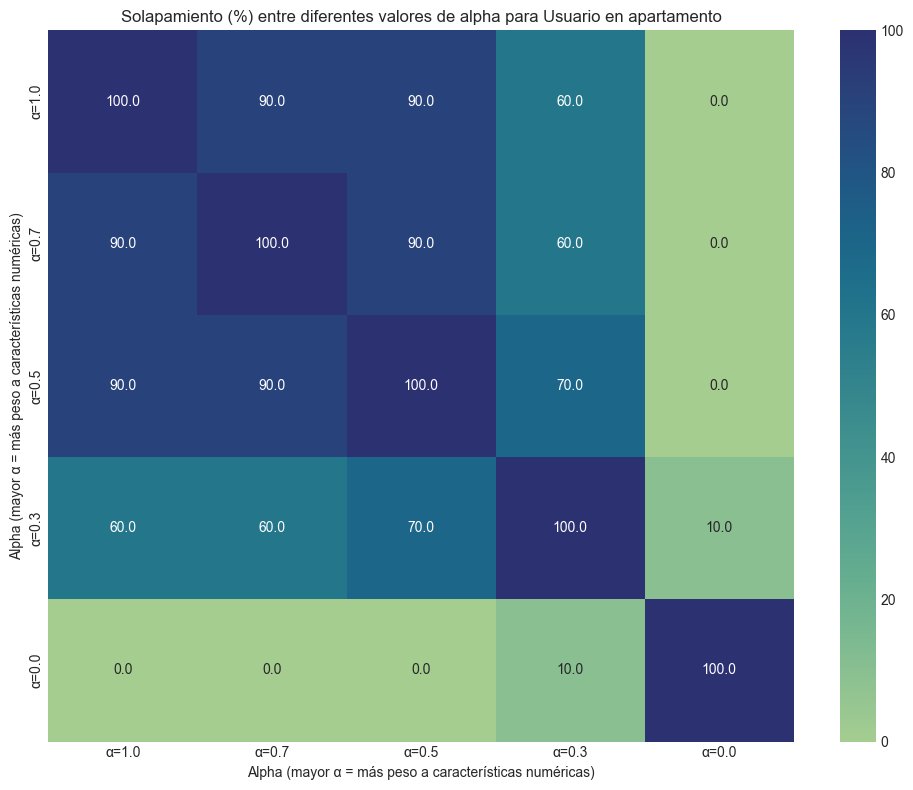

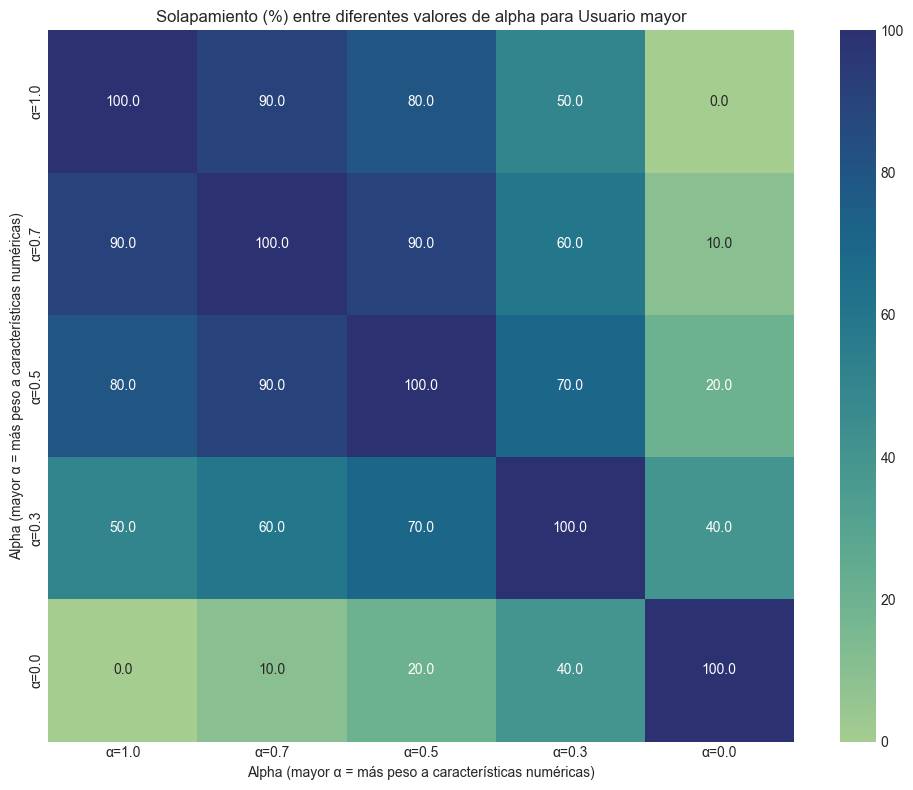

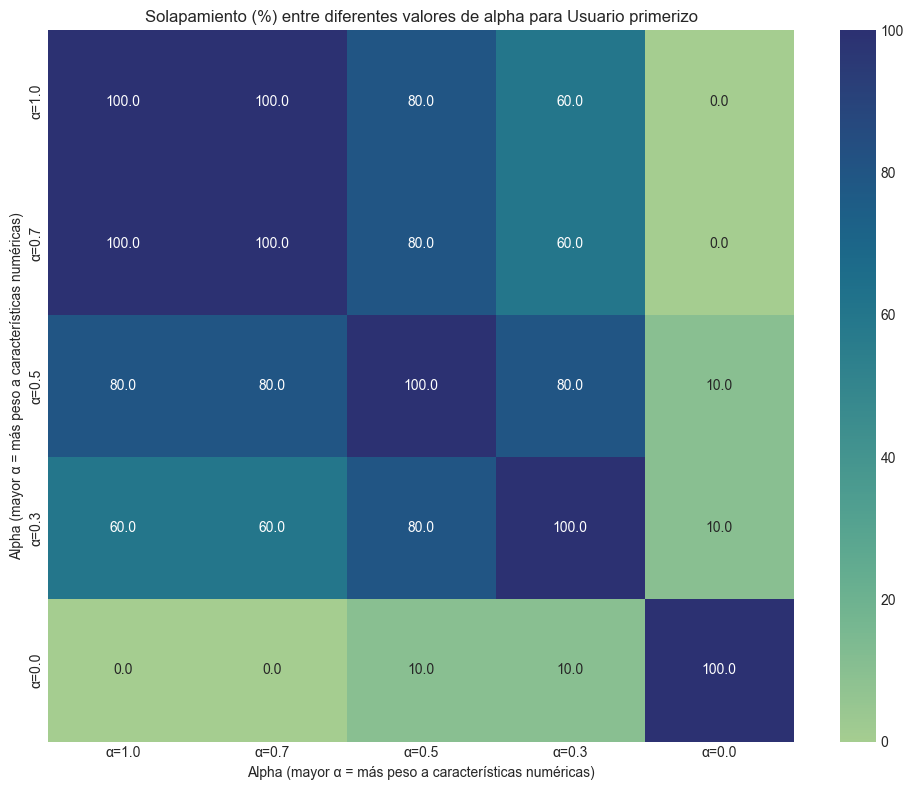

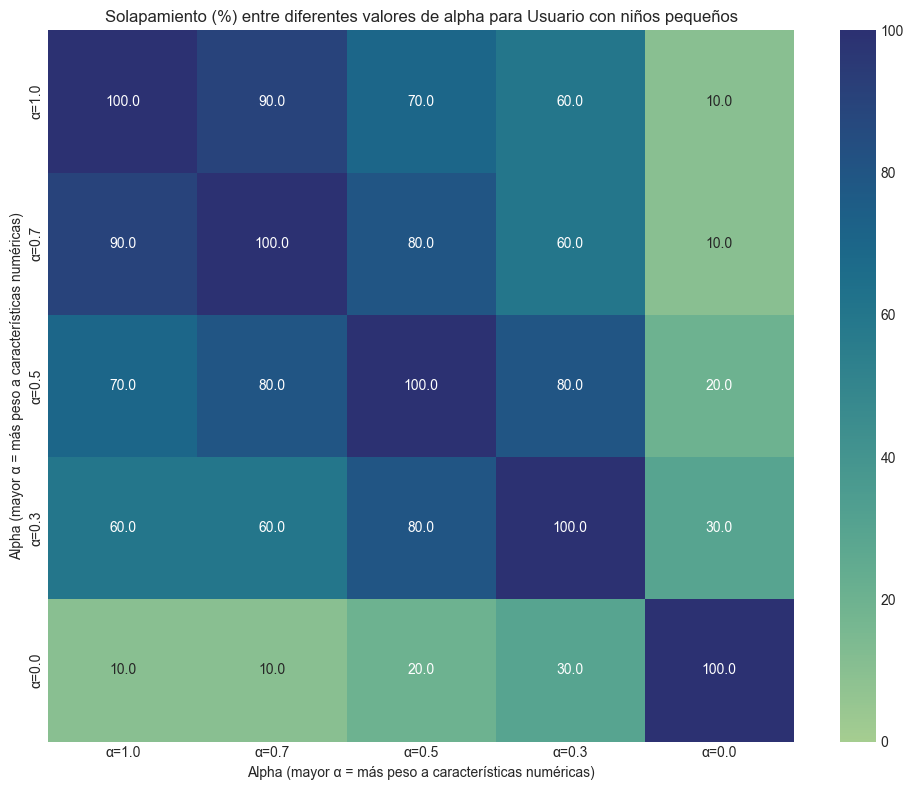

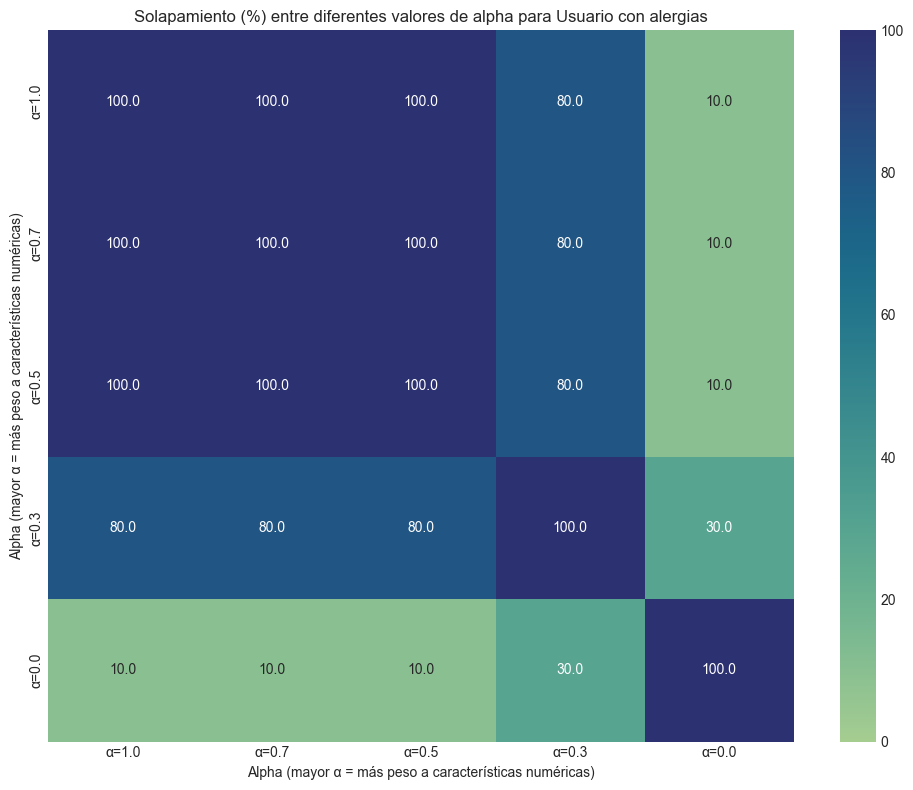

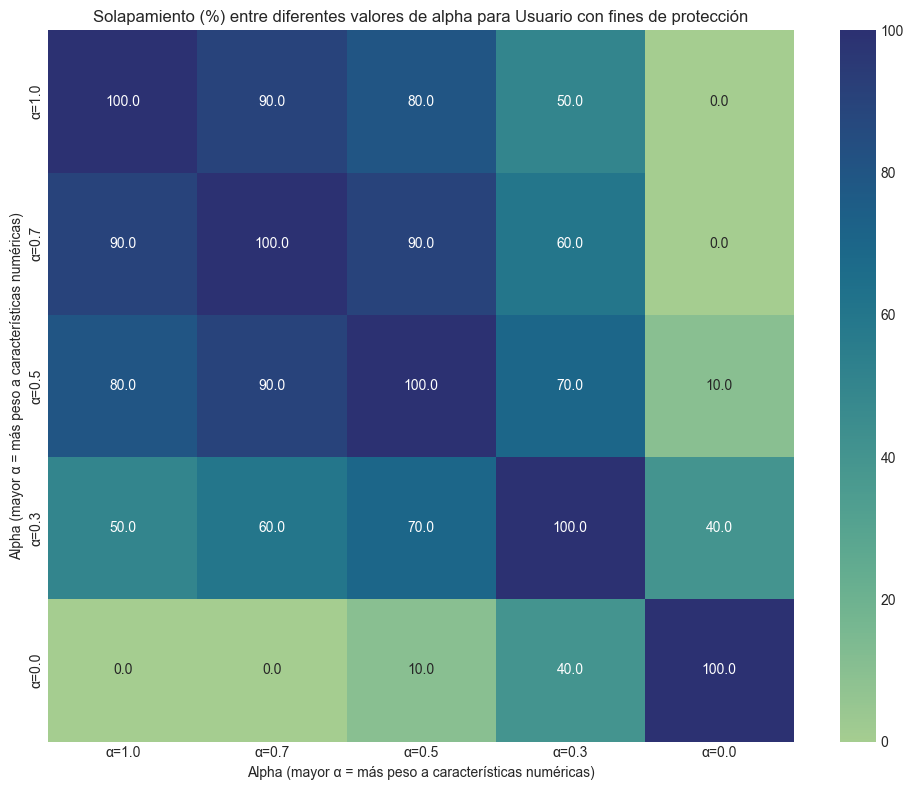

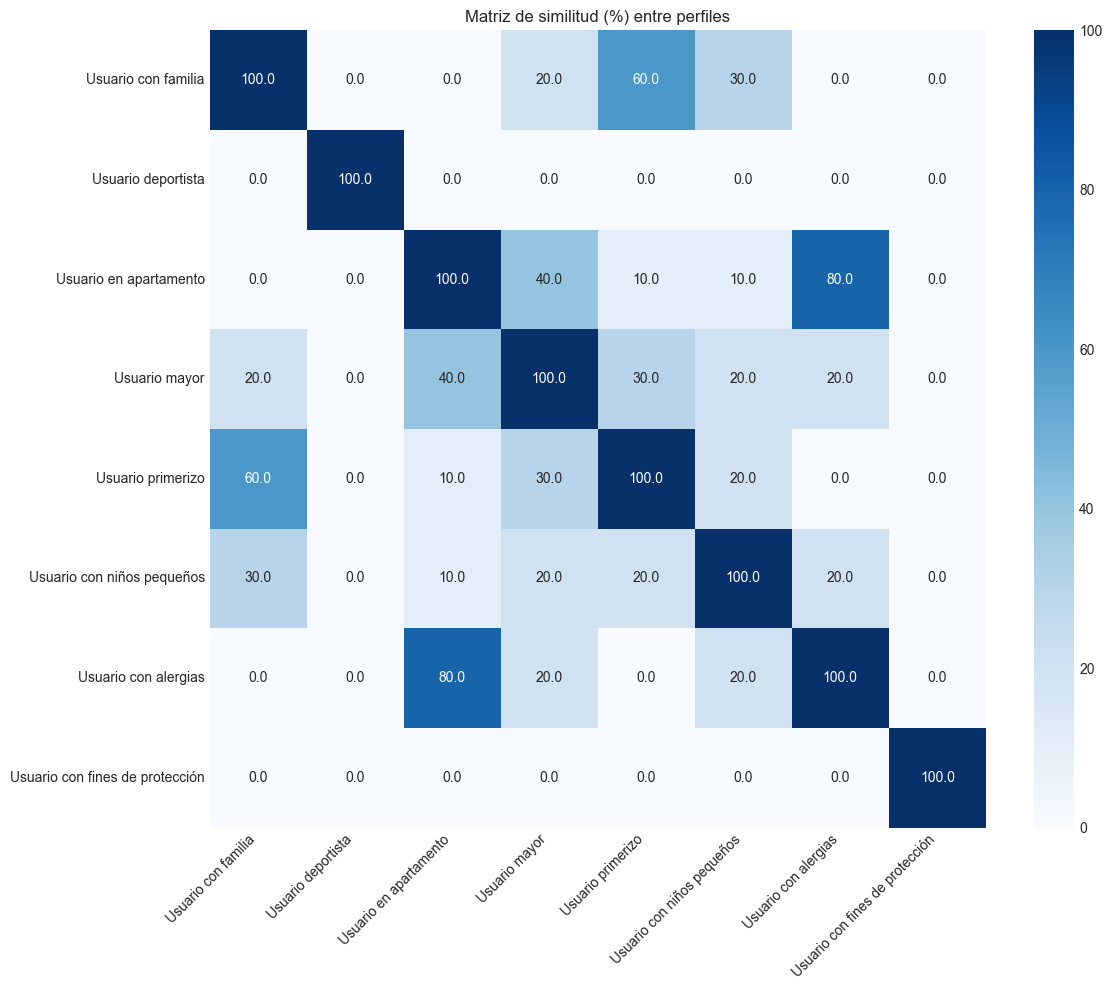

In [18]:
# Analizamos el solapamiento entre recomendaciones con diferentes valores de alpha
import matplotlib.pyplot as plt
import seaborn as sns

# Para cada perfil, compramos el solapamiento entre diferentes valores de alpha
for profile in test_profiles:
    nombre = profile["nombre"]
    
    # Creamos una matriz de solapamiento
    overlap_matrix = np.zeros((len(alpha_values), len(alpha_values)))
    alpha_labels = [f"{a:.1f}" for a in alpha_values]
    
    # Calculamos solapamiento para cada par de alphas
    for i, alpha1 in enumerate(alpha_values):
        breeds1 = set(all_recommendations[alpha1][nombre]['breed'].tolist())
        
        for j, alpha2 in enumerate(alpha_values):
            breeds2 = set(all_recommendations[alpha2][nombre]['breed'].tolist())
            
            # Calculamos solapamiento como porcentaje
            overlap = len(breeds1.intersection(breeds2))
            overlap_percent = overlap / 10 * 100  # Top-10 recomendaciones
            overlap_matrix[i, j] = overlap_percent
    
    # Visualizamos matriz de solapamiento como mapa de calor
    plt.figure(figsize=(10, 8))
    sns.heatmap(
        overlap_matrix,
        annot=True,
        fmt='.1f',
        cmap='crest',
        xticklabels=[f"α={a}" for a in alpha_labels],
        yticklabels=[f"α={a}" for a in alpha_labels],
        vmin=0,
        vmax=100
    )
    plt.title(f'Solapamiento (%) entre diferentes valores de alpha para {nombre}')
    plt.xlabel('Alpha (mayor α = más peso a características numéricas)')
    plt.ylabel('Alpha (mayor α = más peso a características numéricas)')
    plt.tight_layout()
    plt.show()

# Calculamos y visualizamos la diversidad de razas recomendadas para alpha=0.5
alpha_balanced = 0.5
breeds_by_profile = {nombre: set(all_recommendations[alpha_balanced][nombre]['breed'].tolist()) 
                    for nombre in [p["nombre"] for p in test_profiles]}

# Creamos matriz de solapamiento para visualización
nombres = list(breeds_by_profile.keys())
overlap_matrix = np.zeros((len(nombres), len(nombres)))

# Calculamos el porcentaje de solapamiento para cada par de perfiles
for i, nombre1 in enumerate(nombres):
    for j, nombre2 in enumerate(nombres):
        if i == j:
            # 100% de solapamiento consigo mismo
            overlap_matrix[i, j] = 100
        else:
            # Calcular solapamiento como porcentaje
            overlap = len(breeds_by_profile[nombre1].intersection(breeds_by_profile[nombre2]))
            overlap_percent = overlap / 10 * 100  # Dividimos por 10 porque son top-10 recomendaciones
            overlap_matrix[i, j] = overlap_percent

# Generamos el mapa de calor del solapamiento
plt.figure(figsize=(12, 10))
sns.heatmap(
    overlap_matrix,
    annot=True,
    fmt='.1f',
    cmap='Blues',
    xticklabels=nombres,
    yticklabels=nombres,
    vmin=0,
    vmax=100
)
plt.title(f'Matriz de similitud (%) entre perfiles')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

## **5. Visualización de recomendaciones con configuración balanceada**

Analizamos las recomendaciones utilizando una configuración balanceada entre características numéricas y textuales.

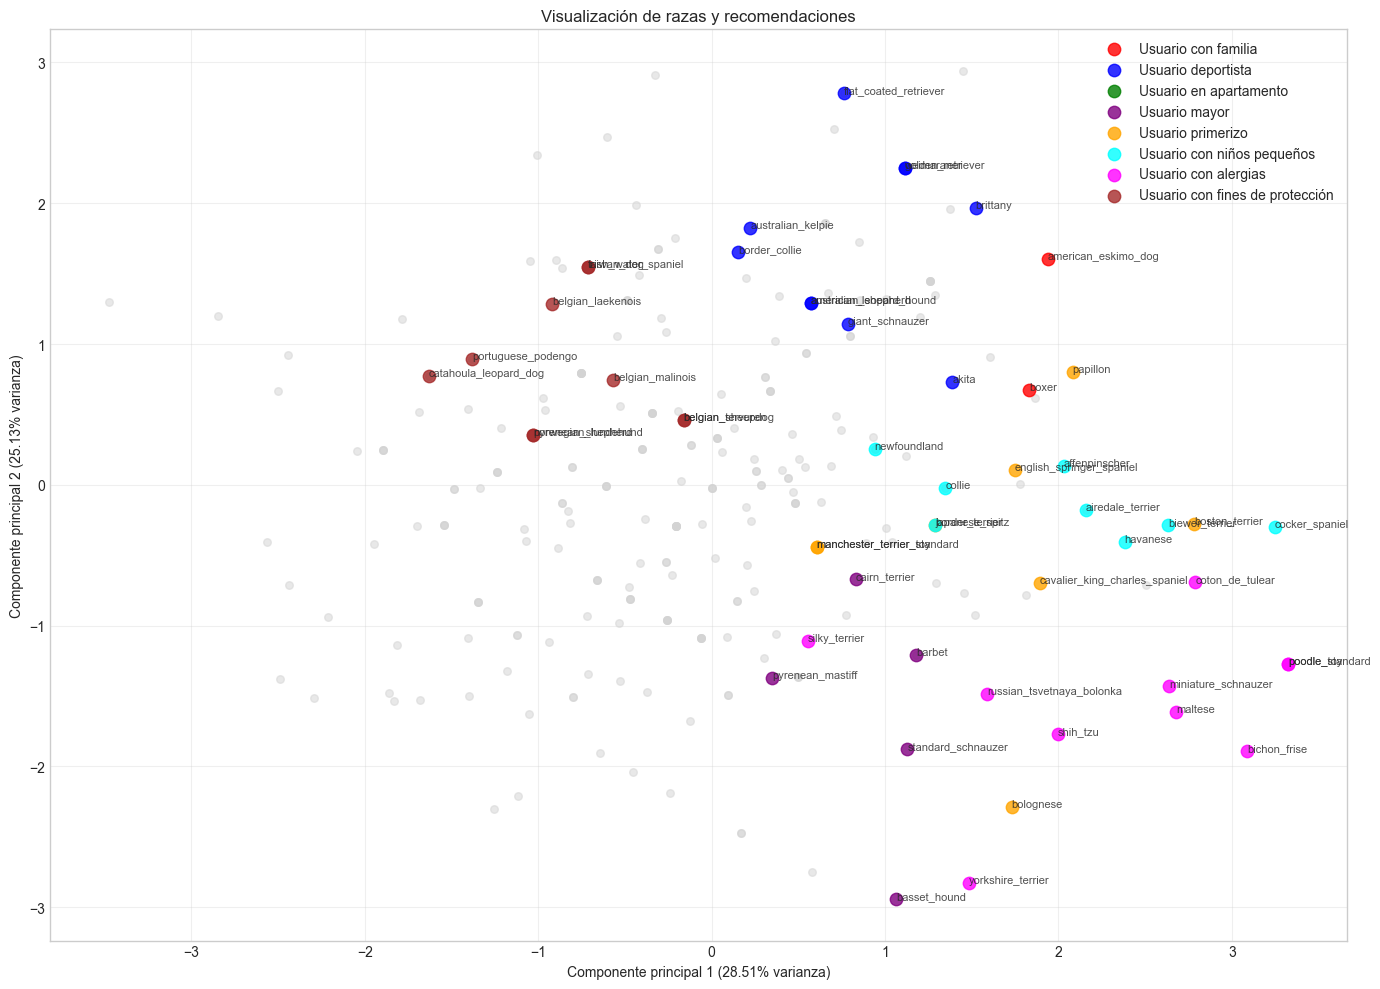

In [14]:
# Usamos alpha = 0.5 (equilibrio entre características numéricas y textuales)
alpha_optimal = 0.5
balanced_recommendations = all_recommendations[alpha_optimal]

# 5.1 Reducimos dimensionalidad para visualización
from sklearn.decomposition import PCA
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_num)

# 5.2 Creamos un DataFrame para visualización
viz_df = pd.DataFrame({
    'x': X_pca[:, 0],
    'y': X_pca[:, 1],
    'breed': df['breed'],
    'group': df['group']
})

# Añadimos información de recomendaciones
viz_df['tipo'] = 'otras'
for nombre, recs in balanced_recommendations.items():
    for breed in recs['breed']:
        viz_df.loc[viz_df['breed'] == breed, 'tipo'] = nombre

# 5.3 Visualizamos las razas y recomendaciones
plt.figure(figsize=(14, 10))

# Mostramos todas las razas en gris claro
plt.scatter(viz_df[viz_df['tipo'] == 'otras']['x'], 
            viz_df[viz_df['tipo'] == 'otras']['y'], 
            c='lightgray', alpha=0.5, s=30)

# Mostramos las recomendaciones de cada perfil con colores distintos
colors = ['red', 'blue', 'green', 'purple', 'orange', 'cyan', 'magenta', 'brown']

for i, nombre in enumerate([p['nombre'] for p in test_profiles]):
    subset = viz_df[viz_df['tipo'] == nombre]
    plt.scatter(subset['x'], subset['y'], 
                c=colors[i % len(colors)], alpha=0.8, s=80, label=nombre)
    
    # Añadimos etiquetas para las razas recomendadas
    for _, row in subset.iterrows():
        plt.annotate(row['breed'], 
                    (row['x'], row['y']),
                    fontsize=8,
                    alpha=0.8)

plt.title(f'Visualización de razas y recomendaciones')
plt.xlabel(f'Componente principal 1 ({pca.explained_variance_ratio_[0]:.2%} varianza)')
plt.ylabel(f'Componente principal 2 ({pca.explained_variance_ratio_[1]:.2%} varianza)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## **6. Evaluación de perfiles simulados**

Evaluamos el rendimiento del modelo híbrido, para ello, se realizó una simulación de los gustos de los perfiles del usuario, esto tomando a las razas con valores cercanos o idénticos al perfil del usuario creado


Razas favoritas simuladas para Usuario con familia:
Modelo numérico: border_terrier, japanese_spitz, boston_terrier, havanese, boxer
Modelo híbrido: japanese_spitz, papillon, boston_terrier, border_terrier, cairn_terrier

Razas favoritas simuladas para Usuario deportista:
Modelo numérico: border_collie, brittany, giant_schnauzer, weimaraner, golden_retriever
Modelo híbrido: border_collie, brittany, weimaraner, australian_kelpie, giant_schnauzer

Razas favoritas simuladas para Usuario en apartamento:
Modelo numérico: bolognese, shih_tzu, silky_terrier, russian_tsvetnaya_bolonka, maltese
Modelo híbrido: bolognese, maltese, shih_tzu, basset_hound, silky_terrier

Razas favoritas simuladas para Usuario mayor:
Modelo numérico: bolognese, basset_hound, cairn_terrier, russian_tsvetnaya_bolonka, russian_toy
Modelo híbrido: bolognese, basset_hound, cavalier_king_charles_spaniel, maltese, russian_tsvetnaya_bolonka

Razas favoritas simuladas para Usuario primerizo:
Modelo numérico: cavalier_king_

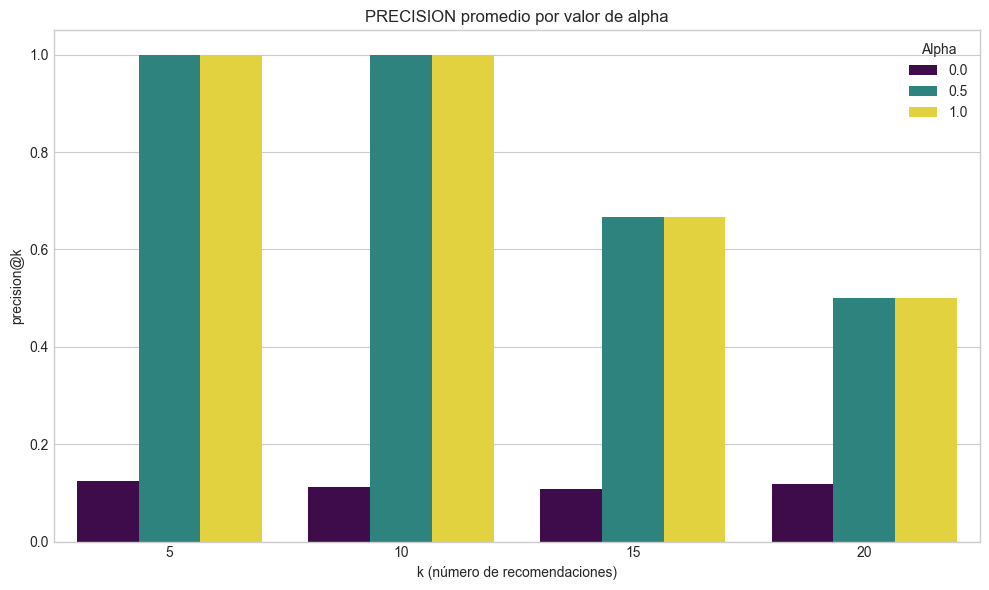


RECALL por alpha (promedios):


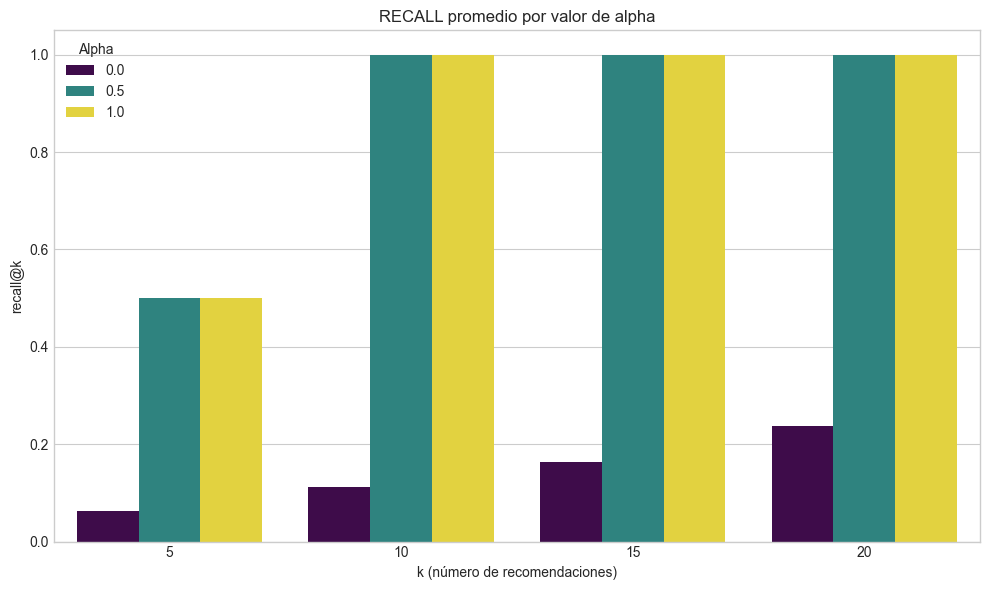


NDCG por alpha (promedios):


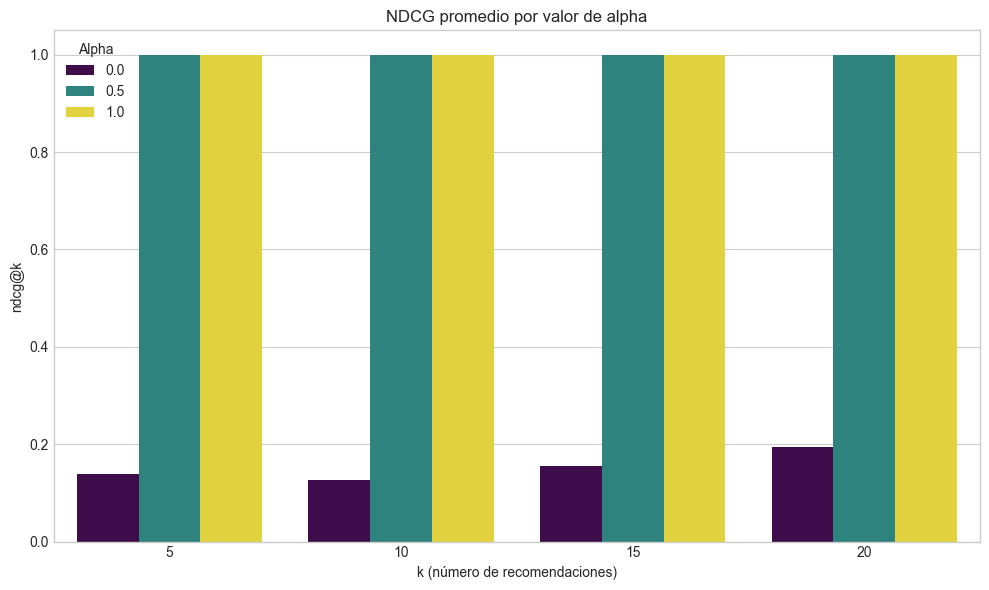

In [15]:
from evaluation.metrics import precision_at_k, recall_at_k, ndcg_at_k

# 6.1 Simulamos usuarios con gustos conocidos
def simulate_user_favorites_hybrid(profile, df, n=10):
    """Simula las razas favoritas de un usuario según su perfil y consulta de texto"""
    # Extraemos preferencias numéricas y texto
    user_profile = {k: profile[k] for k in feature_order}
    user_text = profile.get("text_query", "")
    
    # Generamos vector de usuario
    user_vec = generate_user_vector(user_profile, scaler, feature_order)
    
    # Generaramos similitudes combinadas
    similarities = cosine_similarity(user_vec, X_num)[0]
    
    if user_text:
        text_vec = tfidf_model.transform([user_text])
        text_similarities = cosine_similarity(text_vec, X_text)[0]
        # Combinamos con peso balanceado
        similarities = 0.5 * similarities + 0.5 * text_similarities
    
    # Obtenemos índices de las n razas más similares
    top_indices = np.argsort(similarities)[::-1][:n]
    return df.iloc[top_indices]['breed'].tolist()

# 6.2 Generamos razas favoritas para cada perfil
from sklearn.metrics.pairwise import cosine_similarity

ground_truth_numeric = {}
ground_truth_hybrid = {}

for profile in test_profiles:
    nombre = profile["nombre"]
    # Generamos gustos conocidos solo características numéricas (a=1.0)
    ground_truth_numeric[nombre] = simulate_user_favorites_hybrid(
        {k: profile[k] for k in feature_order}, df, n=10)
    
    # Generamos gustos conocidos con las características combinadas (a=0.5)
    ground_truth_hybrid[nombre] = simulate_user_favorites_hybrid(profile, df, n=10)
    
    print(f"\nRazas favoritas simuladas para {nombre}:")
    print(f"Modelo numérico: {', '.join(ground_truth_numeric[nombre][:5])}")
    print(f"Modelo híbrido: {', '.join(ground_truth_hybrid[nombre][:5])}")

# 6.3 Evaluamos diferentes configuraciones
alphas_to_evaluate = [1.0, 0.5, 0.0]
eval_results = []

for profile in test_profiles:
    nombre = profile["nombre"]
    
    # Extraemos información del perfil
    user_profile = {k: profile[k] for k in feature_order}
    user_text = profile.get("text_query", "")
    
    # Para cada alpha, evaluamos las recomendaciones
    for alpha in alphas_to_evaluate:
        if alpha == 1.0:
            ground_truth = ground_truth_numeric[nombre]
        elif alpha == 0.0:
            ground_truth = ground_truth_hybrid[nombre]
        else:
            ground_truth = ground_truth_hybrid[nombre]
            
        # Generamos recomendaciones por configuración
        user_vec = generate_user_vector(user_profile, scaler, feature_order)
        
        # Recomendar top 20
        recs = recommend_by_content(
            user_vec, X_num, df, top_k=20,
            text_query=user_text,
            text_vectors=X_text,
            tfidf_vectorizer=tfidf_model,
            alpha=alpha
        )
        recommended_breeds = recs['breed'].tolist()
        
        # Calcular métricas
        for k in [5, 10, 15, 20]:
            eval_results.append({
                'perfil': nombre,
                'alpha': alpha,
                'k': k,
                'precision': precision_at_k(recommended_breeds, ground_truth, k),
                'recall': recall_at_k(recommended_breeds, ground_truth, k),
                'ndcg': ndcg_at_k(recommended_breeds, ground_truth, k)
            })

# 6.4 Mostramos resultados
eval_df = pd.DataFrame(eval_results)

# Agrupamos por métrica y alpha
for metric in ['precision', 'recall', 'ndcg']:
    print(f"\n{metric.upper()} por alpha (promedios):")
    pivot = pd.pivot_table(
        eval_df, 
        values=metric, 
        index=['alpha', 'k'], 
        aggfunc='mean'
    ).reset_index()
    
    # Visualizar
    plt.figure(figsize=(10, 6))
    sns.barplot(data=pivot, x='k', y=metric, hue='alpha', palette='viridis')
    plt.title(f'{metric.upper()} promedio por valor de alpha')
    plt.xlabel('k (número de recomendaciones)')
    plt.ylabel(f'{metric}@k')
    plt.legend(title='Alpha')
    plt.tight_layout()
    plt.show()

## **7. Análisis de importancia de características**

Evaluamos la importancia relativa de las características numéricas y textuales en las recomendaciones.

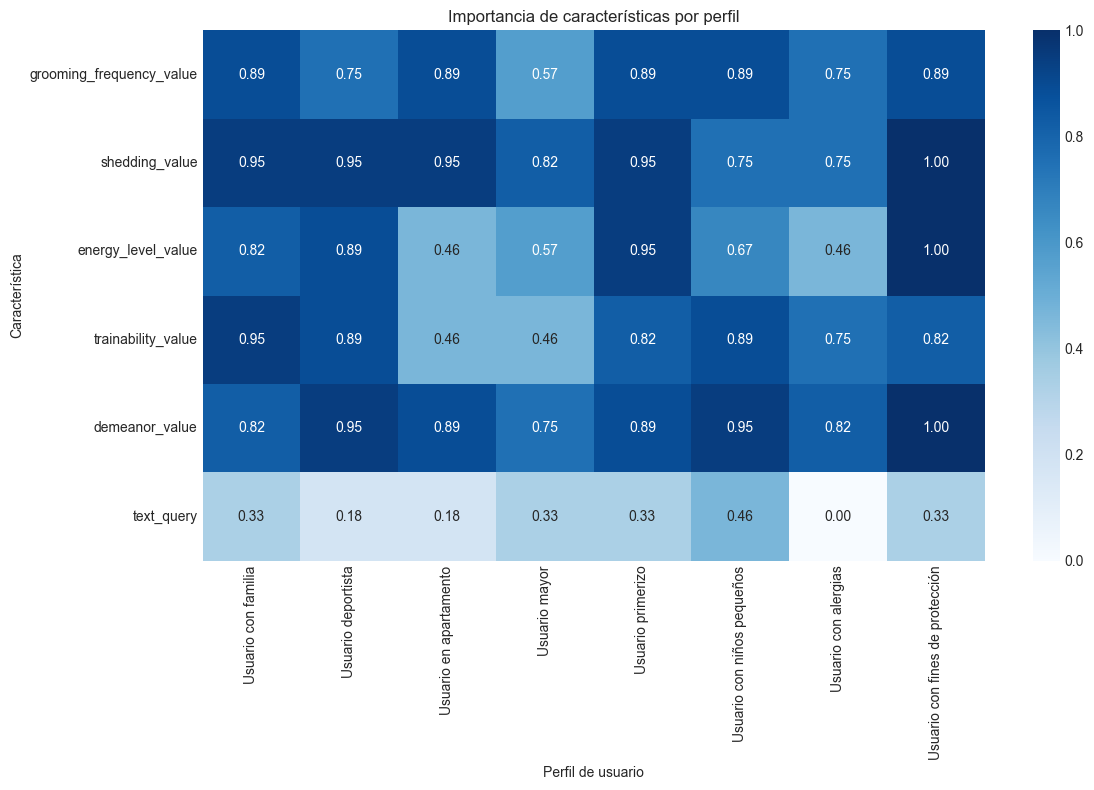

In [17]:
# 7.1 Para el modelo híbrido (alpha=0.5), evaluamos la importancia de cada característica
alpha_optimal = 0.5
feature_importance = pd.DataFrame(index=feature_order + ["text_query"])

# Para cada perfil de usuario, medimos el cambio en las recomendaciones al modificar una característica
for profile in test_profiles:
    nombre = profile['nombre']                                                          
    base_profile = {k: profile[k] for k in feature_order}                                
    base_text_query = profile.get("text_query", "")
    
    # Recomendaciones base
    base_user_vec = generate_user_vector(base_profile, scaler, feature_order)
    base_recs = recommend_by_content(
        base_user_vec, 
        X_num, 
        df, 
        top_k=10,
        text_query=base_text_query,
        text_vectors=X_text,
        tfidf_vectorizer=tfidf_model,
        alpha=alpha_optimal
    )['breed'].tolist()
    
    # Para cada característica numérica, medimos el cambio al modificarla
    changes = {}
    for feature in feature_order:
        # Creamos un perfil con esta característica cambiada
        modified_profile = base_profile.copy()
        
        # Modificamos la característica (reducimos o aumentamos según el caso)
        current_value = base_profile[feature]
        if current_value > 0.5:
            modified_profile[feature] = max(0.1, current_value - 0.4)
        else:
            modified_profile[feature] = min(0.9, current_value + 0.4)
        
        # Generamos recomendaciones con el perfil modificado
        modified_vector = generate_user_vector(modified_profile, scaler, feature_order)
        modified_recs = recommend_by_content(
            modified_vector, 
            X_num, 
            df, 
            top_k=10,
            text_query=base_text_query,
            text_vectors=X_text,
            tfidf_vectorizer=tfidf_model,
            alpha=alpha_optimal
        )['breed'].tolist()
        
        # Calculamos la similitud de Jaccard entre las listas
        jaccard = len(set(base_recs) & set(modified_recs)) / len(set(base_recs) | set(modified_recs))
        
        # 1 - Jaccard = cambio (0 = sin cambio, 1 = cambio total)
        changes[feature] = 1 - jaccard
    
    # Evaluamos la importancia de la consulta de texto
    if base_text_query:
        # Generamos recomendaciones sin consulta de texto
        text_modified_recs = recommend_by_content(
            base_user_vec, 
            X_num, 
            df, 
            top_k=10,
            text_query=None,  # Sin consulta de texto
            text_vectors=X_text,
            tfidf_vectorizer=tfidf_model,
            alpha=1.0  # Solo numérico
        )['breed'].tolist()
        
        # Calculamos similitud de Jaccard
        jaccard = len(set(base_recs) & set(text_modified_recs)) / len(set(base_recs) | set(text_modified_recs))
        changes["text_query"] = 1 - jaccard
    else:
        changes["text_query"] = 0.0
    
    # Añadimos al DataFrame
    feature_importance[nombre] = pd.Series(changes)

# Visualizamos importancia de características
plt.figure(figsize=(12, 8))
sns.heatmap(feature_importance, annot=True, cmap='Blues', fmt='.2f')
plt.title(f'Importancia de características por perfil')
plt.ylabel('Característica')
plt.xlabel('Perfil de usuario')
plt.tight_layout()
plt.show()

## **8. Conclusiones y optimizaciones**

El modelo mejorado de filtrado basado en contenido ofrece varias ventajas:

1. **Incorporación completa de información**: Al utilizar tanto características numéricas como textuales (TF-IDF), aprovechamos toda la información disponible sobre las razas de perros.

2. **Mayor flexibilidad**: El parámetro alpha permite ajustar el peso relativo entre características numéricas y textuales según las necesidades específicas.

3. **Personalización mejorada**: Las consultas de texto permiten capturar aspectos específicos de las preferencias de los usuarios que pueden no estar representados en las características numéricas.

4. **Mayor diversidad de recomendaciones**: La combinación de diferentes tipos de información puede conducir a una mayor diversidad en las recomendaciones.

Posibles optimizaciones futuras:

- Ajuste automático de alpha basado en el perfil del usuario
- Incorporación de aprendizaje sobre preferencias de usuario para ajustar pesos
- Integración con filtrado colaborativo en un sistema híbrido más avanzado
- Diversificación explícita mediante MMR (Maximal Marginal Relevance)